In [23]:
%matplotlib inline 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

import numpy as np

#### 1. Use RandomForestClassifier in sklearn

In [2]:
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [3]:
# feature matrix 
wine.data.shape

(178, 13)

In [ ]:
# target matrix
wine.target.shape # 3 categories

(178,)

In [5]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, test_size=0.3)

In [6]:
# class instantiation and train
clf = DecisionTreeClassifier(random_state=0)
rfc = RandomForestClassifier(random_state=0)

# training
clf = clf.fit(Xtrain, Ytrain)
rfc = rfc.fit(Xtrain, Ytrain)

# testing
score_c = clf.score(Xtest, Ytest)
score_r = rfc.score(Xtest, Ytest)

print("Single Tree:{}".format(score_c), 
      "Random Forest:{}".format(score_r))

Single Tree:0.9074074074074074 Random Forest:0.9814814814814815


#### 2. Use learning rate to fine-tuning n_estimators

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [31]:
# ----- time warning -----
# learning curve
superpa = []
for i in range(200):
    rfc = RandomForestClassifier(n_estimators=i+1, n_jobs=-1)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    superpa.append(rfc_s)
print(max(superpa), superpa.index(max(superpa)))
plt.fiture(figsize=[20,5])
plt.plot(range(1,201), superpa)
plt.show()

KeyboardInterrupt: 

#### 3. Compare decision tree and random forest

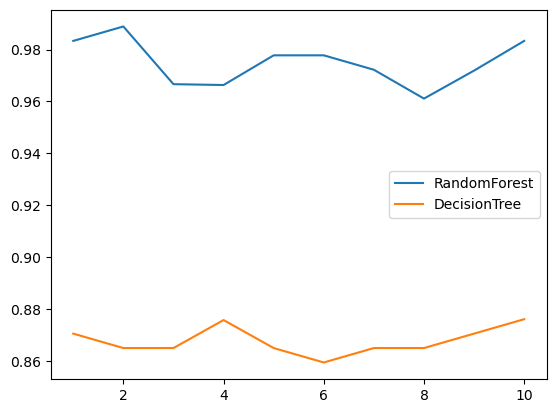

In [30]:
rfc_l = []
clf_l = []

for i in range(10):
    rfc = RandomForestClassifier(n_estimators=25)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    rfc_l.append(rfc_s)

    clf = DecisionTreeClassifier()
    clf_s = cross_val_score(clf, wine.data, wine.target, cv=10).mean()
    clf_l.append(clf_s)

plt.plot(range(1,11), rfc_l, label="RandomForest")
plt.plot(range(1,11), clf_l, label="DecisionTree")
plt.legend()
plt.show()

#### 4. Parameter: random_state

In [32]:
rfc = RandomForestClassifier(n_estimators=25, random_state=2)
rfc = rfc.fit(Xtrain, Ytrain)

In [36]:
# key properties in RF: estimators - check the trees in the forest
rfc.estimators_[0].random_state

1872583848

In [ ]:
rfc.estimators_[5].random_state
# differnet trees have difference random state!

1922988331

#### 5. Parameter: oob_score (use OOB data to test)

In [37]:
# don't need to divide data as testing/training data
rfc = RandomForestClassifier(n_estimators=25, oob_score=True)
rfc = rfc.fit(wine.data, wine.target)

In [ ]:
# key property: oob_score_
rfc.oob_score_     # accuracy

0.9719101123595506

#### 6. API of RandomForestClassifier

In [39]:
rfc = RandomForestClassifier(n_estimators=25)
rfc = rfc.fit(Xtrain, Ytrain)

In [40]:
rfc.score(Xtest, Ytest)

0.9814814814814815

In [ ]:
rfc.feature_importances_ # importance score of each feature

array([0.15370939, 0.02504715, 0.00588291, 0.01136848, 0.05634777,
       0.04318634, 0.19955957, 0.00711216, 0.01212486, 0.10751465,
       0.06937327, 0.1653641 , 0.14340935])

In [ ]:
rfc.apply(Xtest) 
# return the index of the leaf containing the sample in each tree

array([[16, 12, 11, ..., 18,  8, 15],
       [ 9,  9,  7, ..., 11,  6,  7],
       [12,  5,  2, ..., 11,  1,  8],
       ...,
       [ 7,  7,  7, ..., 10,  7, 11],
       [13,  5,  2, ..., 18,  6, 13],
       [ 7,  7,  6, ..., 15,  1,  7]])

In [43]:
rfc.predict(Xtest) # return predicted target

array([0, 1, 1, 2, 1, 0, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 2, 0, 1, 1, 1, 2,
       2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 1, 1, 2, 0, 1, 2, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 2, 1, 2, 2, 1, 1])

In [ ]:
rfc.predict_proba(Xtest)
# return the probabilities of belonging to three categories for each sample

array([[0.96, 0.04, 0.  ],
       [0.04, 0.72, 0.24],
       [0.  , 1.  , 0.  ],
       [0.  , 0.04, 0.96],
       [0.32, 0.68, 0.  ],
       [1.  , 0.  , 0.  ],
       [0.96, 0.04, 0.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.04, 0.88, 0.08],
       [0.  , 1.  , 0.  ],
       [0.92, 0.08, 0.  ],
       [0.  , 0.88, 0.12],
       [0.96, 0.  , 0.04],
       [0.76, 0.24, 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [1.  , 0.  , 0.  ],
       [0.04, 0.96, 0.  ],
       [0.04, 0.96, 0.  ],
       [0.08, 0.8 , 0.12],
       [0.  , 0.16, 0.84],
       [0.  , 0.08, 0.92],
       [0.  , 0.24, 0.76],
       [0.96, 0.04, 0.  ],
       [0.  , 1.  , 0.  ],
       [0.92, 0.08, 0.  ],
       [0.  , 0.84, 0.16],
       [1.  , 0.  , 0.  ],
       [0.8 , 0.2 , 0.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 0.12, 0.88],
       [0.  , 1.  , 0.  ],
       [0.24, 0.76, 0.  ],
       [0.  , 0.28, 0.72],
       [0.88, 0.08, 0.04],
 